# 🌿 Plant Disease Classification — PlantVillage Dataset

**Dataset:** [PlantVillage Dataset (Kaggle)](https://www.kaggle.com/datasets/tushar5harma/plant-village-dataset-updated)

**Pendekatan:**
1. Simple CNN (baseline)
2. Transfer Learning (MobileNetV2)
3. Siamese Network + Prototype Classifier
4. **Hybrid CNN-ViT** (pendekatan dari pustaka)

**Pustaka:**
- Kumar et al. (2024). *A Hybrid Framework for Plant Leaf Disease Detection and Classification using CNN and Vision Transformer.* Complex & Intelligent Systems. https://link.springer.com/article/10.1007/s40747-024-01764-x
- Thakur et al. (2022). *Explainable Vision Transformer Enabled CNN for Plant Disease Identification (PlantXViT).* arXiv. https://arxiv.org/abs/2207.07919

## 0. Setup & Instalasi

In [ ]:
!pip install kagglehub -q
!pip install tensorflow -q

In [ ]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout,
    Lambda, GlobalAveragePooling2D, BatchNormalization,
    LayerNormalization, MultiHeadAttention, Reshape, Layer
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import kagglehub

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load Dataset

In [ ]:
path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")
BASE_DIR = path
print("Path to dataset files:", path)

# ================================================================
# HYPERPARAMETER — disesuaikan penuh dengan kode teman
# ================================================================
IMG_SIZE   = 224
BATCH_SIZE = 32
EMBED_DIM  = 128
MARGIN     = 1.0
EPOCHS     = 30          # ← sama dengan teman (bukan 10)
LR         = 1e-4
SEED       = 42

# Siamese parameters — sama dengan teman
N_PAIRS_TRAIN    = 100   # n_pairs_per_class train
N_PAIRS_VAL      = 20    # n_pairs_per_class val
MAX_PROTO        = 50    # max_per_class prototype
MAX_EVAL         = 30    # max_per_class evaluasi
N_TSNE_PER_CLASS = 30    # n_per_class t-SNE

# CNN/TL — lebih banyak data
MAX_PER_CLASS_TRAIN = 300
MAX_PER_CLASS_VAL   = 80
MAX_PER_CLASS_TEST  = 80

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Path to dataset files: /kaggle/input/plant-village-dataset-updated


In [ ]:
all_train_data_dirs = []
all_val_data_dirs   = []
all_test_data_dirs  = []
all_class_names     = set()

for plant_type_folder in sorted(os.listdir(BASE_DIR)):
    plant_type_path = os.path.join(BASE_DIR, plant_type_folder)
    if os.path.isdir(plant_type_path):
        train_path = os.path.join(plant_type_path, 'Train')
        val_path   = os.path.join(plant_type_path, 'Val')
        test_path  = os.path.join(plant_type_path, 'Test')
        if os.path.isdir(train_path):
            all_train_data_dirs.append(train_path)
            for cls in sorted(os.listdir(train_path)):
                if os.path.isdir(os.path.join(train_path, cls)):
                    all_class_names.add(cls)
        if os.path.isdir(val_path):  all_val_data_dirs.append(val_path)
        if os.path.isdir(test_path): all_test_data_dirs.append(test_path)

CLASS_NAMES  = sorted(list(all_class_names))
N_CLASSES    = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Jumlah kelas : {N_CLASSES}')
print(f'Contoh kelas : {CLASS_NAMES[:5]}')

Jumlah kelas : 16
Contoh kelas : ['Apple Scab', 'Bacterial Spot', 'Black Rot', 'Cedar Apple Rust', 'Cercospora Leaf Spot']


In [ ]:
def build_class_dict(data_dir):
    class_dict = {}
    for cls in sorted(os.listdir(data_dir)):
        cls_path = os.path.join(data_dir, cls)
        if os.path.isdir(cls_path):
            imgs = [os.path.join(cls_path, f)
                    for f in os.listdir(cls_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if imgs:
                class_dict[cls] = imgs
    return class_dict

train_class_dict = {}
val_class_dict   = {}
test_class_dict  = {}

for d in all_train_data_dirs: train_class_dict.update(build_class_dict(d))
for d in all_val_data_dirs:   val_class_dict.update(build_class_dict(d))
for d in all_test_data_dirs:  test_class_dict.update(build_class_dict(d))

total_train = sum(len(v) for v in train_class_dict.values())
print(f'Total gambar train : {total_train}')
print(f'Contoh kelas       : {list(train_class_dict.keys())[:3]}')

Total gambar train : 29325
Contoh kelas       : ['Apple Scab', 'Black Rot', 'Cedar Apple Rust']


### 1.1 Visualisasi Sampel Dataset

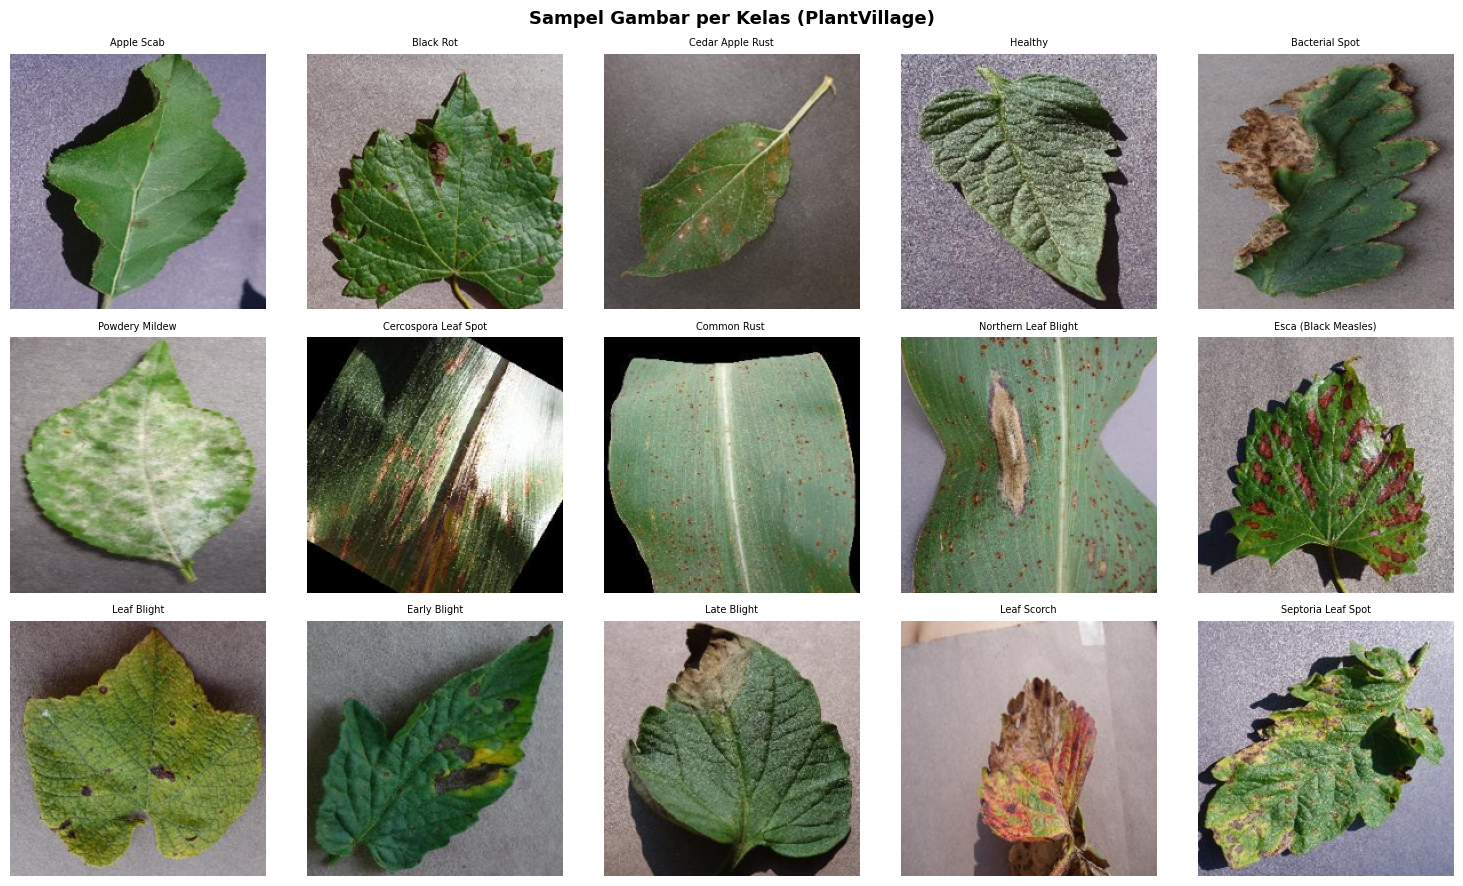

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, cls in zip(axes.flat, list(train_class_dict.keys())[:15]):
    img = Image.open(random.choice(train_class_dict[cls])).convert('RGB').resize((224,224))
    ax.imshow(img); ax.set_title(cls[:28], fontsize=7); ax.axis('off')
plt.suptitle('Sampel Gambar per Kelas (PlantVillage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.2 DataGenerator untuk CNN

In [ ]:
import shutil

FLAT_TRAIN = '/tmp/flat_train'
FLAT_VAL   = '/tmp/flat_val'
FLAT_TEST  = '/tmp/flat_test'

def build_flat_dir(class_dict, flat_dir, max_per_class=300):
    if os.path.exists(flat_dir): shutil.rmtree(flat_dir)
    os.makedirs(flat_dir)
    for cls, imgs in class_dict.items():
        cls_dir = os.path.join(flat_dir, cls)
        os.makedirs(cls_dir, exist_ok=True)
        for src in imgs[:max_per_class]:
            dst = os.path.join(cls_dir, os.path.basename(src))
            if not os.path.exists(dst): shutil.copy2(src, dst)
    n = sum(len(os.listdir(os.path.join(flat_dir,c)))
            for c in os.listdir(flat_dir)
            if os.path.isdir(os.path.join(flat_dir,c)))
    print(f'Flat dir siap: {flat_dir} ({n} gambar)')

build_flat_dir(train_class_dict, FLAT_TRAIN, MAX_PER_CLASS_TRAIN)
build_flat_dir(val_class_dict,   FLAT_VAL,   MAX_PER_CLASS_VAL)
build_flat_dir(test_class_dict,  FLAT_TEST,  MAX_PER_CLASS_TEST)

Flat dir siap: /tmp/flat_train (4800 gambar)
Flat dir siap: /tmp/flat_val (1280 gambar)
Flat dir siap: /tmp/flat_test (739 gambar)


In [ ]:
# Augmentasi lebih kuat untuk generalisasi lebih baik
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    FLAT_TRAIN, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
val_gen = val_datagen.flow_from_directory(
    FLAT_VAL, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
test_gen = val_datagen.flow_from_directory(
    FLAT_TEST, target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False, seed=SEED)

N_CLASSES_GEN = len(train_gen.class_indices)
print(f'N_CLASSES dari generator : {N_CLASSES_GEN}')

Found 4800 images belonging to 16 classes.
Found 1280 images belonging to 16 classes.
Found 739 images belonging to 16 classes.
N_CLASSES dari generator : 16


---
## 2. Simple CNN (Baseline)

In [ ]:
def build_simple_cnn(input_shape=(224,224,3), n_classes=N_CLASSES_GEN):
    """4 blok Conv2D + BN + Dropout, diakhiri GAP + Dense head."""
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',padding='same',input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2), Dropout(0.1),

        Conv2D(64,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        Conv2D(64,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2), Dropout(0.1),

        Conv2D(128,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        Conv2D(128,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2), Dropout(0.2),

        Conv2D(256,(3,3),activation='relu',padding='same'),
        BatchNormalization(),
        Conv2D(256,(3,3),activation='relu',padding='same'),
        MaxPooling2D(2,2), Dropout(0.2),

        GlobalAveragePooling2D(),
        Dense(512,activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(256,activation='relu'), Dropout(0.3),
        Dense(n_classes,activation='softmax')
    ], name='SimpleCNN')
    return model

simple_cnn = build_simple_cnn()
simple_cnn.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.summary()

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,443,248 (5.51 MB)

 Trainable params: 1,441,264 (5.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_simple_cnn.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

print('Training Simple CNN...')
t0 = time.time()
history_cnn = simple_cnn.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks_cnn, verbose=1
)
print(f'Selesai dalam {time.time()-t0:.1f}s')

Training Simple CNN...
Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.9377 - loss: 0.1897

150/150 ━━━━━━━━━━━━━━━━━━━━ 95s 636ms/step - accuracy: 0.9360 - loss: 0.1905 - val_accuracy: 0.8516 - val_loss: 0.4434 - learning_rate: 5.0000e-05
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9321 - loss: 0.1847

150/150 ━━━━━━━━━━━━━━━━━━━━ 80s 528ms/step - accuracy: 0.9342 - loss: 0.1963 - val_accuracy: 0.8859 - val_loss: 0.3637 - learning_rate: 5.0000e-05
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 509ms/step - accuracy: 0.9408 - loss: 0.1822 - val_accuracy: 0.8492 - val_loss: 0.5194 - learning_rate: 5.0000e-05
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 516ms/step - accuracy: 0.9350 - loss: 0.1913 - val_accuracy: 0.8414 - val_loss: 0.4721 - learning_rate: 5.0000e-05
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9386 - loss: 0.1847

150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 517ms/step - accuracy: 0.9400 - loss: 0.1817 - val_accuracy: 0.9359 - val_loss: 0.2100 - learning_rate: 5.0000e-05
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 78s 519ms/step - accuracy: 0.9456 - loss: 0.1636 - val_accuracy: 0.9109 - val_loss: 0.2782 - learning_rate: 5.0000e-05
Epoch 7/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 76s 507ms/step - accuracy: 0.9456 - loss: 0.1646 - val_accuracy: 0.9086 - val_loss: 0.2703 - learning_rate: 5.0000e-05
Epoch 8/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 516ms/step - accuracy: 0.9390 - loss: 0.1820 - val_accuracy: 0.8922 - val_loss: 0.3105 - learning_rate: 5.0000e-05
Epoch 9/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9426 - loss: 0.1707
Epoch 9: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 515ms/step - accuracy: 0.9400 - loss: 0.1747 - val_accuracy: 0.8805 - val_loss: 0.3697 - learning_rate: 5.0000e-05
Epoch 10/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 77s 515ms/step - accur

Simple CNN — Test Loss: 0.2432 | Test Acc: 92.02%


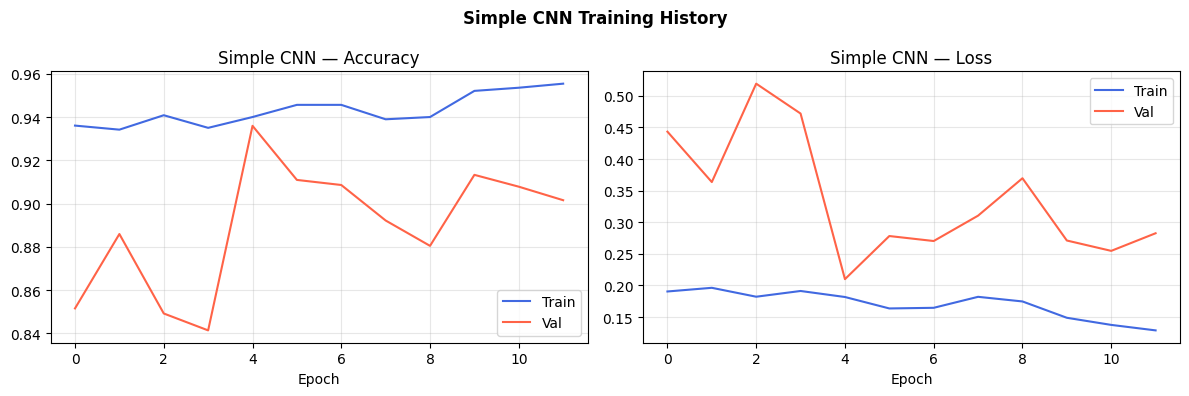

In [ ]:
cnn_test_loss, cnn_test_acc = simple_cnn.evaluate(test_gen, verbose=0)
print(f'Simple CNN — Test Loss: {cnn_test_loss:.4f} | Test Acc: {cnn_test_acc*100:.2f}%')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(history_cnn.history['accuracy'], label='Train', color='royalblue')
ax1.plot(history_cnn.history['val_accuracy'], label='Val', color='tomato')
ax1.set_title('Simple CNN — Accuracy'); ax1.legend(); ax1.grid(True,alpha=0.3)
ax2.plot(history_cnn.history['loss'], label='Train', color='royalblue')
ax2.plot(history_cnn.history['val_loss'], label='Val', color='tomato')
ax2.set_title('Simple CNN — Loss'); ax2.legend(); ax2.grid(True,alpha=0.3)
for ax in [ax1,ax2]: ax.set_xlabel('Epoch')
plt.suptitle('Simple CNN Training History', fontweight='bold')
plt.tight_layout(); plt.savefig('simple_cnn_history.png',dpi=150); plt.show()

---
## 3. Transfer Learning — MobileNetV2

In [ ]:
def build_mobilenetv2_model(input_shape=(224,224,3), n_classes=N_CLASSES_GEN, fine_tune_at=80):
    """
    MobileNetV2 fine-tuning.
    fine_tune_at=80 → lebih banyak layer trainable → akurasi lebih tinggi.
    """
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:fine_tune_at]: layer.trainable = False

    inputs = Input(shape=input_shape)
    x = base(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs, name='MobileNetV2_TL')

tl_model = build_mobilenetv2_model()
tl_model.compile(optimizer=Adam(LR), loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,052,368 (11.64 MB)

 Trainable params: 2,831,632 (10.80 MB)

 Non-trainable params: 220,736 (862.25 KB)

In [ ]:
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_mobilenetv2.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

print('Training MobileNetV2 Transfer Learning...')
t0 = time.time()
history_tl = tl_model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks_tl, verbose=1
)
print(f'Selesai dalam {time.time()-t0:.1f}s')

Training MobileNetV2 Transfer Learning...
Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.3547 - loss: 2.2936

150/150 ━━━━━━━━━━━━━━━━━━━━ 115s 502ms/step - accuracy: 0.5373 - loss: 1.5531 - val_accuracy: 0.6172 - val_loss: 1.3412 - learning_rate: 1.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8119 - loss: 0.6030

150/150 ━━━━━━━━━━━━━━━━━━━━ 70s 468ms/step - accuracy: 0.8325 - loss: 0.5366 - val_accuracy: 0.6922 - val_loss: 1.2088 - learning_rate: 1.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 462ms/step - accuracy: 0.8856 - loss: 0.3522 - val_accuracy: 0.6859 - val_loss: 1.2119 - learning_rate: 1.0000e-04
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9082 - loss: 0.2754

150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 481ms/step - accuracy: 0.9142 - loss: 0.2581 - val_accuracy: 0.7617 - val_loss: 0.9705 - learning_rate: 1.0000e-04
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9408 - loss: 0.2001

150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 462ms/step - accuracy: 0.9396 - loss: 0.1965 - val_accuracy: 0.7766 - val_loss: 0.8981 - learning_rate: 1.0000e-04
Epoch 6/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9446 - loss: 0.1682

...

150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 480ms/step - accuracy: 0.9746 - loss: 0.0775 - val_accuracy: 0.9242 - val_loss: 0.2900 - learning_rate: 1.0000e-04
Epoch 13/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.9790 - loss: 0.0665 - val_accuracy: 0.9164 - val_loss: 0.3262 - learning_rate: 1.0000e-04
Epoch 14/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9833 - loss: 0.0557

150/150 ━━━━━━━━━━━━━━━━━━━━ 74s 491ms/step - accuracy: 0.9833 - loss: 0.0560 - val_accuracy: 0.9320 - val_loss: 0.2614 - learning_rate: 1.0000e-04
Epoch 15/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9855 - loss: 0.0476

150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 481ms/step - accuracy: 0.9837 - loss: 0.0545 - val_accuracy: 0.9500 - val_loss: 0.1927 - learning_rate: 1.0000e-04
Epoch 16/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9880 - loss: 0.0466

150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 474ms/step - accuracy: 0.9879 - loss: 0.0474 - val_accuracy: 0.9664 - val_loss: 0.1407 - learning_rate: 1.0000e-04
Epoch 17/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 73s 484ms/step - accuracy: 0.9873 - loss: 0.0425 - val_accuracy: 0.9609 - val_loss: 0.1317 - learning_rate: 1.0000e-04
Epoch 18/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 476ms/step - accuracy: 0.9840 - loss: 0.0488 - val_accuracy: 0.9664 - val_loss: 0.1239 - learning_rate: 1.0000e-04
Epoch 19/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9859 - loss: 0.0509

150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 480ms/step - accuracy: 0.9858 - loss: 0.0488 - val_accuracy: 0.9766 - val_loss: 0.0915 - learning_rate: 1.0000e-04
Epoch 20/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 483ms/step - accuracy: 0.9823 - loss: 0.0511 - val_accuracy: 0.9711 - val_loss: 0.0866 - learning_rate: 1.0000e-04
Epoch 21/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 476ms/step - accuracy: 0.9867 - loss: 0.0451 - val_accuracy: 0.9758 - val_loss: 0.0764 - learning_rate: 1.0000e-04
Epoch 22/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 473ms/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.9445 - val_loss: 0.1708 - learning_rate: 1.0000e-04
Epoch 23/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 72s 478ms/step - accuracy: 0.9902 - loss: 0.0361 - val_accuracy: 0.9578 - val_loss: 0.1356 - learning_rate: 1.0000e-04
Epoch 24/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 474ms/step - accuracy: 0.9890 - loss: 0.0360 - val_accuracy: 0.9695 - val_loss: 0.1146 - learning_rate: 1.0000e-04
Epoch 25/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/st

MobileNetV2 TL — Test Loss: 0.1502 | Test Acc: 95.67%


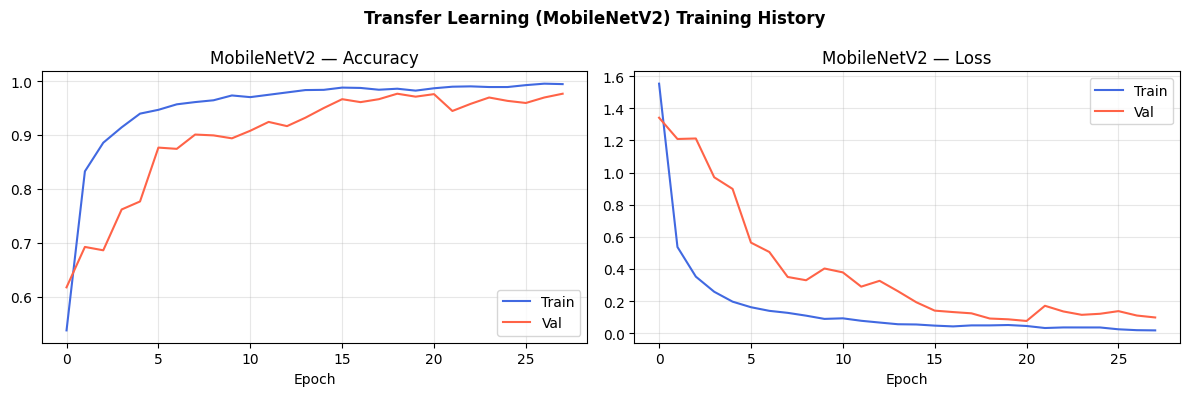

In [ ]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_gen, verbose=0)
print(f'MobileNetV2 TL — Test Loss: {tl_test_loss:.4f} | Test Acc: {tl_test_acc*100:.2f}%')

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(history_tl.history['accuracy'], label='Train', color='royalblue')
ax1.plot(history_tl.history['val_accuracy'], label='Val', color='tomato')
ax1.set_title('MobileNetV2 — Accuracy'); ax1.legend(); ax1.grid(True,alpha=0.3)
ax2.plot(history_tl.history['loss'], label='Train', color='royalblue')
ax2.plot(history_tl.history['val_loss'], label='Val', color='tomato')
ax2.set_title('MobileNetV2 — Loss'); ax2.legend(); ax2.grid(True,alpha=0.3)
for ax in [ax1,ax2]: ax.set_xlabel('Epoch')
plt.suptitle('Transfer Learning (MobileNetV2) Training History', fontweight='bold')
plt.tight_layout(); plt.savefig('mobilenetv2_history.png',dpi=150); plt.show()